In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df=pd.read_csv('UpdatedResumeDataSet.csv')

In [118]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [119]:
df.shape

(962, 2)

In [120]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

In [121]:
df.Category.unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

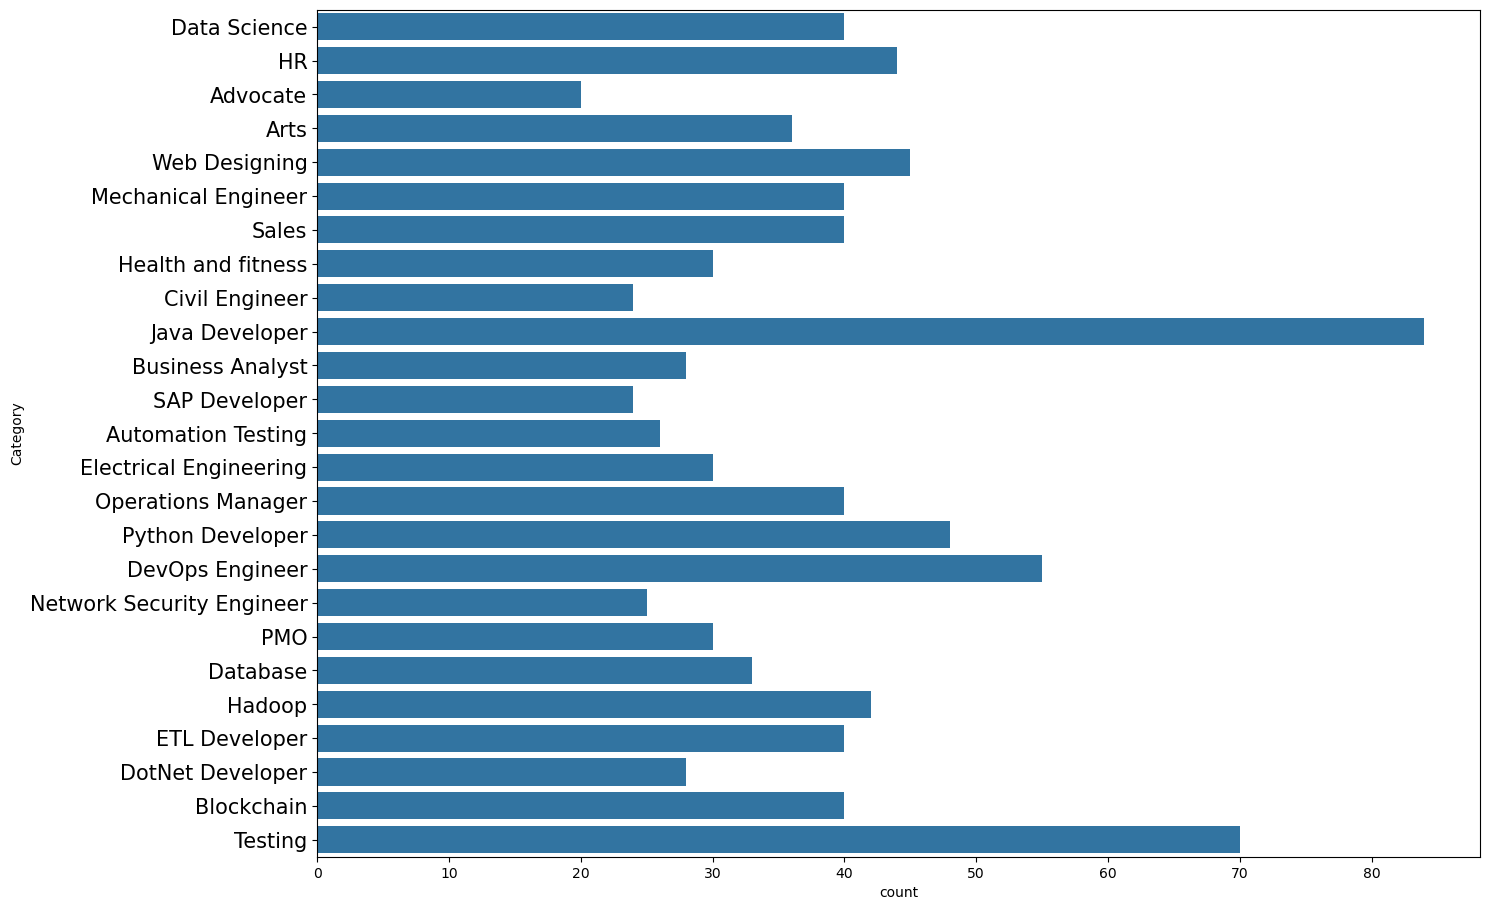

In [122]:
plt.figure(figsize=(15,11))
sns.countplot(df['Category'])
plt.yticks(size=15)
plt.show()

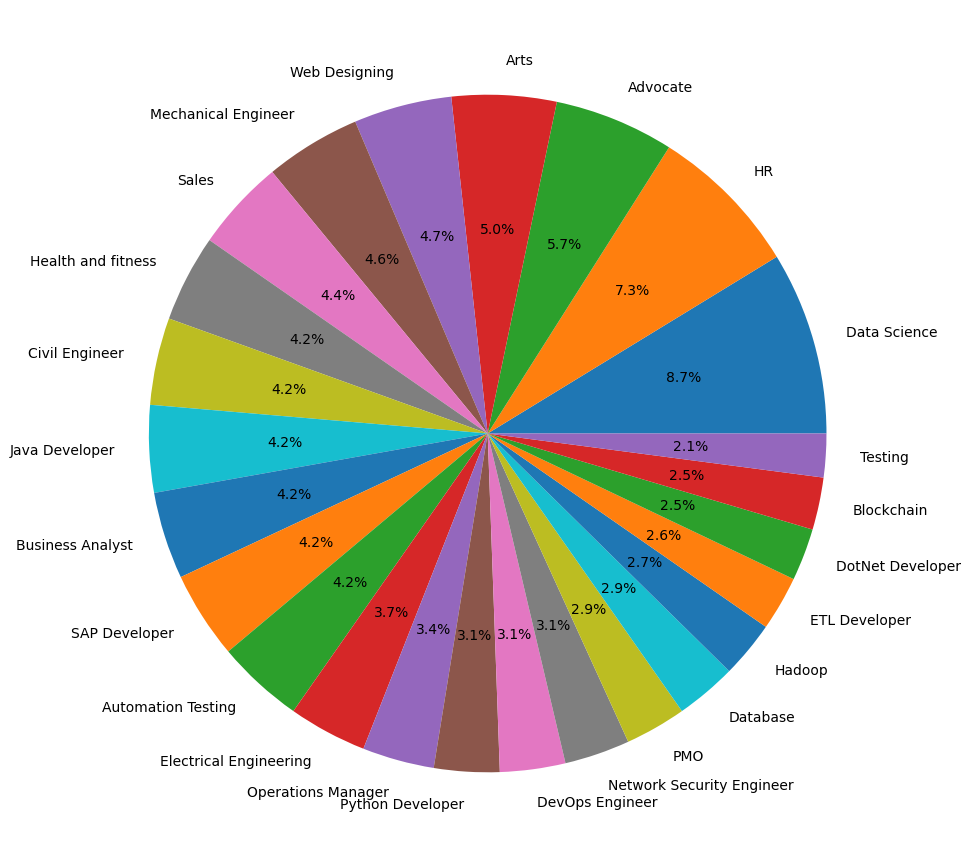

In [123]:
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(15,11))
plt.pie(counts,labels=labels,autopct='%1.1f%%')
plt.show()


### Cleaning Data

In [124]:
df['Resume'][0]


'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

1 url
2 hashtags
3 special letters
4 puntuation

In [125]:
import re

def CleanResume(txt):
    cleanTxt = re.sub(r'http\S+\s*', ' ', txt)
    cleanTxt = re.sub(r'@\S+', ' ', cleanTxt)
    cleanTxt = re.sub(r'#\S+', ' ', cleanTxt)
    cleanTxt = re.sub(r'RT|cc', ' ', cleanTxt)
    cleanTxt = re.sub(r'[^\w\s]', ' ', cleanTxt)
    cleanTxt = re.sub(r'\s+', ' ', cleanTxt)
    return cleanTxt

In [126]:
df['Resume']=df['Resume'].apply(lambda x: CleanResume(x))

In [127]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM NaÃ ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the

## word into categorical values

In [128]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [129]:
le.fit(df['Category'])
df['Category']=le.transform(df['Category'])


In [130]:
df['Category']

0       6
1       6
2       6
3       6
4       6
       ..
957    23
958    23
959    23
960    23
961    23
Name: Category, Length: 962, dtype: int32

In [131]:
df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [132]:
# array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
#        'Mechanical Engineer', 'Sales', 'Health and fitness',
#        'Civil Engineer', 'Java Developer', 'Business Analyst',
#        'SAP Developer', 'Automation Testing', 'Electrical Engineering',
#        'Operations Manager', 'Python Developer', 'DevOps Engineer',
#        'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
#        'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
#       dtype=object)

## vectorization

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
requredtext=tfidf.transform(df['Resume'])

In [134]:
requredtext

<962x7384 sparse matrix of type '<class 'numpy.float64'>'
	with 164335 stored elements in Compressed Sparse Row format>

## Spliting

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(requredtext, df['Category'], test_size=0.2, random_state=42)

In [137]:
X_train.shape

(769, 7384)

In [138]:
X_test.shape

(193, 7384)

## Train the model

In [147]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

clf=KNeighborsClassifier()
clf.fit(X_train,y_train)
ypred=clf.predict(X_test)

print(accuracy_score(y_test,ypred))

0.9844559585492227


## Prediction system

In [150]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf,open('clf.pkl','wb'))


In [167]:
myresume = """
John Doe is an experienced Network Security Engineer with over 7 years of expertise in designing, implementing, and managing network security infrastructures. Specializing in safeguarding critical network systems, John has worked with various organizations to protect against cyber threats, data breaches, and unauthorized access. He is proficient in deploying firewalls, intrusion detection systems (IDS), VPNs, and network monitoring tools to ensure the integrity and security of networks.

John holds a degree in Computer Science and certifications in several cybersecurity domains, including Certified Information Systems Security Professional (CISSP), Certified Ethical Hacker (CEH), and Cisco Certified Network Associate (CCNA). He has extensive experience in troubleshooting and resolving network vulnerabilities, and has played a key role in conducting security audits and risk assessments.

Key Skills:
- Network Security Architecture
- Firewall Management and Configuration
- Intrusion Detection and Prevention Systems (IDS/IPS)
- Virtual Private Networks (VPNs)
- Security Audits and Risk Assessments
- Cybersecurity Incident Response
- Network Monitoring and Traffic Analysis
- Vulnerability Assessment and Penetration Testing
- Data Encryption and Secure Communications

Certifications:
- CISSP (Certified Information Systems Security Professional)
- CEH (Certified Ethical Hacker)
- CCNA (Cisco Certified Network Associate)
- CompTIA Security+

Education:
BSc in Computer Science, XYZ University, 2012-2016

Professional Experience:
- Network Security Engineer at ABC Corp (2016-Present)
- IT Security Specialist at DEF Solutions (2014-2016)

Languages:
- English (Fluent)
- French (Intermediate)
"""

In [168]:
cleaned_resume = CleanResume(myresume) 
input_features=tfidf.transform([cleaned_resume])
prediction_id=clf.predict(input_features)[0]
category_mapping = {
    6: "Data Science",
    12: "HR",
    0: "Advocate",
    1: "Arts",
    24: "Web Designing",
    16: "Mechanical Engineer",
    22: "Sales",
    14: "Health and fitness",
    5: "Civil Engineer",
    15: "Java Developer",
    4: "Business Analyst",
    21: "SAP Developer",
    2: "Automation Testing",
    11: "Electrical Engineering",
    18: "Operations Manager",
    20: "Python Developer",
    8: "DevOps Engineer",
    17: "Network Security Engineer",
    19: "PMO",
    7: "Database",
    13: "Hadoop",
    10: "ETL Developer",
    9: "DotNet Developer",
    3: "Blockchain",
    23: "Testing"
}
category_name=category_mapping.get(prediction_id,"Unknow")
print("prediction category:",category_name)
print(prediction_id)


prediction category: Network Security Engineer
17
